# PyTorch for Economic Analytics: Theory & Hands-On Projects

A complete, self-contained notebook that teaches PyTorch fundamentals — tensors, autograd, and full training pipelines — and applies every concept to a **trending topic in economics: macroeconomic forecasting and recession prediction.**

Central banks, investment firms, and governments increasingly use machine learning on leading indicators (yield curves, unemployment, inflation, consumer confidence) to **nowcast GDP growth** and **anticipate recessions** months in advance. This notebook builds that pipeline from first principles.

**Contents**
1. What is PyTorch? (quick refresher)
2. Tensors: Theory & Creation — using macroeconomic indicator data
3. Mathematical Operations on Tensors — computing growth rates & composite indices
4. Shapes, Reshaping & Dimensions — batching country/quarter panel data
5. Autograd: Gradients in PyTorch
6. Project 1 — Linear Regression: Nowcasting GDP Growth
7. Datasets & DataLoaders — a macroeconomic indicators dataset
8. Building a Neural Network (`nn.Module`)
9. Project 2 — **Recession Prediction** from the Yield Curve & Leading Indicators (binary classification)
10. Project 3 — Challenge: **Economic Regime Classification** (Expansion / Slowdown / Recession)
11. Wrap-up & Key Takeaways


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.14.0+cu130
CUDA available: False


## 1. What is PyTorch? (Quick Refresher)

**PyTorch** is a Python-based, open-source deep learning library built around:

1. **Dynamic computation graphs** — the graph is built on the fly as operations run ("define-by-run"), making it easy to debug and experiment.
2. **Tensors with GPU acceleration** — NumPy-like arrays that can run on GPU via `.to('cuda')`.
3. **`torch.nn`** — ready-made layers and loss functions, assembled into custom `nn.Module` subclasses.
4. **Autograd** — automatic differentiation: PyTorch tracks every tensor operation and computes gradients for you.
5. **A rich ecosystem** for research and production.

### Why economic analytics?

**Trending topic: machine learning for macroeconomic forecasting & recession risk.** A famous, real-world example is the **New York Fed's recession-probability model**, which feeds the **10-year minus 3-month Treasury yield spread** into a statistical model to estimate the probability of a U.S. recession within the next 12 months. When the yield curve **inverts** (short-term rates exceed long-term rates), it has historically preceded most U.S. recessions.

More broadly, economists and analysts now use ML on:
- **Leading indicators** (yield curve, PMI, consumer confidence, jobless claims) to **nowcast GDP growth** before official statistics are released.
- **Recession classifiers** to flag elevated downturn risk for policymakers and investors.
- **Regime-detection models** (expansion / slowdown / recession) to guide monetary policy and portfolio allocation.

Every technique below (tensors → autograd → training loop → evaluation) is the same machinery behind these real systems — we're just applying it to representative macroeconomic data.

### The PyTorch workflow (unchanged, regardless of domain)

1. Define your model by subclassing `torch.nn.Module`.
2. Prepare `DataLoader`s to feed input batches.
3. Choose an optimizer (`SGD`, `Adam`) and a loss function.
4. Run a training loop: forward pass → compute loss → `.backward()` → update parameters.


## 2. Tensors: Theory & Creation

A **tensor** organizes numbers along one or more axes:

- **Scalar (0D)** — e.g. this quarter's inflation rate: `3.2`
- **Vector (1D)** — e.g. one quarter's indicator snapshot: `[interest_rate, inflation, unemployment]`
- **Matrix (2D)** — e.g. a **panel** of quarters: rows = quarters, columns = indicators
- **Higher-D tensor (3D+)** — e.g. indicators tracked per **country**, per **quarter**: (countries, quarters, indicators)

PyTorch tensors behave like NumPy arrays (same indexing/slicing) but add **GPU acceleration** and **autograd** integration — exactly what we need to train forecasting models on economic time series.


In [2]:
# A single quarter's macro snapshot: [interest_rate %, inflation %, unemployment %]
quarter = torch.tensor([5.25, 3.2, 4.1])
print("Quarter vector:", quarter, "| shape:", quarter.shape)

# A panel of 4 consecutive quarters (2D tensor: rows=quarters, cols=indicators)
panel = torch.tensor([
    [5.25, 3.2, 4.1],
    [5.50, 3.6, 4.0],
    [5.50, 4.1, 3.9],
    [5.00, 4.6, 4.3],
])
print("\nMacro panel:\n", panel)
print("shape:", panel.shape)  # (4 quarters, 3 indicators)


Quarter vector: 

tensor([5.2500, 3.2000, 4.1000]) | shape: torch.Size([3])

Macro panel:
 tensor([[5.2500, 3.2000, 4.1000],
        [5.5000, 3.6000, 4.0000],
        [5.5000, 4.1000, 3.9000],
        [5.0000, 4.6000, 4.3000]])
shape: torch.Size([4, 3])


In [3]:
# --- Practical task: build a 3D tensor directly (no intermediate variable) ---
# GDP growth & unemployment for 2 countries, 3 quarters each: [gdp_growth %, unemployment %]
country_panel_3d = torch.tensor([
    [[2.1, 4.0], [1.8, 4.2], [1.2, 4.6]],   # country A, quarters 1-3
    [[0.5, 6.1], [-0.3, 6.5], [-0.8, 7.0]], # country B, quarters 1-3 (slipping into recession)
])
print(country_panel_3d)
print("shape:", country_panel_3d.shape)  # (2 countries, 3 quarters, 2 indicators)


tensor([[[ 2.1000,  4.0000],
         [ 1.8000,  4.2000],
         [ 1.2000,  4.6000]],

        [[ 0.5000,  6.1000],
         [-0.3000,  6.5000],
         [-0.8000,  7.0000]]])
shape: torch.Size([2, 3, 2])


### Built-in tensor-creation functions

| Function | Produces | Economic-analytics use |
|---|---|---|
| `torch.zeros(*size)` | All zeros | Placeholder panel before data is released |
| `torch.ones(*size)` | All ones | Equal-weighted index vector |
| `torch.arange(start,end,step)` | Regular sequence (end exclusive) | Quarter indices in a time series |
| `torch.linspace(start,end,steps)` | Evenly spaced values (inclusive) | A grid of interest-rate scenarios |
| `torch.rand` / `torch.randn` / `torch.randint` | Random values | Initializing model weights |


In [4]:
# Zeros = a placeholder panel for 5 quarters x 3 indicators, not yet released
data_placeholder = torch.zeros(5, 3)
print("Empty panel:\n", data_placeholder)

# arange: quarter indices 1..20 (a 5-year span)
quarters = torch.arange(1, 21)
print("\nQuarter indices:", quarters)

# linspace: an interest-rate scenario grid from 0% to 6%, 7 points
rate_scenarios = torch.linspace(0, 6, steps=7)
print("\nInterest-rate scenarios (%):", rate_scenarios)


Empty panel:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

Quarter indices: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20])

Interest-rate scenarios (%): tensor([0., 1., 2., 3., 4., 5., 6.])


In [5]:
torch.manual_seed(42)

# --- Practical challenge: initializing weights/biases for a small NN, economics-flavored ---
# Layer 1: maps 4 macro indicators -> 6 hidden units
weights_layer1 = torch.rand(4, 6)              # uniform [0,1) init (didactic; real nets use Xavier/He)
biases_layer1  = torch.zeros(1, 6)             # zero-initialized biases
weights_layer2 = torch.randint(-5, 6, (6, 2))  # toy integer weights, layer 2 (2 outputs: recession / no recession)

print("Weights layer 1:\n", weights_layer1)
print("Biases layer 1:\n", biases_layer1)
print("Weights layer 2:\n", weights_layer2)


Weights layer 1:
 tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408, 0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411, 0.4294, 0.8854, 0.5739],
        [0.2666, 0.6274, 0.2696, 0.4414, 0.2969, 0.8317]])
Biases layer 1:
 tensor([[0., 0., 0., 0., 0., 0.]])
Weights layer 2:
 tensor([[-2, -5],
        [-4,  5],
        [-2, -1],
        [-2,  0],
        [-1, -5],
        [ 3, -2]])


## 3. Mathematical Operations with Tensors

- **Element-wise** ops (`+ - * /`) apply per-element — e.g. computing a quarter-over-quarter growth rate.
- **Matrix multiplication** (`torch.matmul` / `@`) — e.g. combining several indicators into a single composite index using fixed weights.
- **Aggregations** (`sum`, `mean`, `max` with `dim=`) — e.g. annual averages, peak unemployment, and normalized index construction.


In [6]:
gdp_q1 = torch.tensor([100.0, 210.0, 55.0])   # billions, 3 regions
gdp_q2 = torch.tensor([102.0, 208.0, 56.5])

print("QoQ change (level):", gdp_q2 - gdp_q1)
print("QoQ growth rate (%):", (gdp_q2 - gdp_q1) / gdp_q1 * 100)


QoQ change (level): tensor([ 2.0000, -2.0000,  1.5000])
QoQ growth rate (%): tensor([ 2.0000, -0.9524,  2.7273])


In [7]:
# Composite Leading Economic Index: 3 quarters x 4 sub-indicators, weighted -> single index value
sub_indicators = torch.tensor([
    [1.2, -0.5, 0.8, 2.1],   # quarter 1: [avg weekly hours, jobless claims (inv), new orders, stock prices]
    [0.9, -0.2, 0.5, 1.0],   # quarter 2
    [-0.3, 0.6, -0.4, -1.5], # quarter 3 (deteriorating)
])
component_weights = torch.tensor([0.3, 0.25, 0.25, 0.2])   # sums to 1

# matmul: (3x4) @ (4,) -> (3,) composite index per quarter
leading_index = torch.matmul(sub_indicators, component_weights)
print("Composite Leading Index by quarter:", leading_index)


Composite Leading Index by quarter: tensor([ 0.8550,  0.5450, -0.3400])


In [8]:
# --- Practical challenge: computing summary statistics across a macro panel ---
# rows = 3 countries, cols = 3 quarters of GDP growth (%)
gdp_growth = torch.tensor([[2.5, 2.1, 1.8], [0.4, -0.2, -0.9], [3.1, 3.4, 3.0]])

country_avg_growth = gdp_growth.mean(dim=1, keepdim=True)  # avg growth per country, dims retained
quarter_avg_growth = gdp_growth.mean(dim=0)                 # avg growth per quarter (cross-country)
country_best_quarter = gdp_growth.max(dim=1)[0]             # each country's strongest quarter
overall_total = gdp_growth.sum()                            # grand total (rarely meaningful, but demonstrates .sum())
normalized_growth = gdp_growth / overall_total              # share of "total" growth captured by each cell

print("GDP growth (%):\n", gdp_growth)
print("Per-country average growth:\n", country_avg_growth)
print("Per-quarter average growth:", quarter_avg_growth)
print("Per-country best quarter:", country_best_quarter)
print("Normalized growth:\n", normalized_growth)


GDP growth (%):
 tensor([[ 2.5000,  2.1000,  1.8000],
        [ 0.4000, -0.2000, -0.9000],
        [ 3.1000,  3.4000,  3.0000]])
Per-country average growth:
 tensor([[ 2.1333],
        [-0.2333],
        [ 3.1667]])
Per-quarter average growth: tensor([2.0000, 1.7667, 1.3000])
Per-country best quarter: tensor([2.5000, 0.4000, 3.4000])
Normalized growth:
 tensor([[ 0.1645,  0.1382,  0.1184],
        [ 0.0263, -0.0132, -0.0592],
        [ 0.2039,  0.2237,  0.1974]])


## 4. Shapes, Reshaping & Dimensions

- `.shape` — inspect a tensor's dimensions.
- `.view()` / `.reshape()` — reorganize data without copying (view) or safely even if non-contiguous (reshape).
- `.unsqueeze()` / `.squeeze()` — add/remove a singleton axis, e.g. turning a single indicator series into `(n, 1)` for feeding into a linear layer.

This matters constantly in economic data work: statistical agencies often publish flat CSVs that must be reshaped into `(observations, indicators)` panels before modeling.


In [9]:
# Suppose a data release gives us one long flat list of 12 numbers:
# 4 quarters x 3 indicators each (interest_rate, inflation, unemployment), flattened.
flat_release = torch.tensor([5.25, 3.2, 4.1,
                              5.50, 3.6, 4.0,
                              5.50, 4.1, 3.9,
                              5.00, 4.6, 4.3])

panel_matrix = flat_release.view(4, 3)   # reshape into (quarters, indicators) — shares memory
print("Reshaped into (quarters, indicators):\n", panel_matrix)

# unsqueeze: turn one column (e.g. inflation) into a (4,1) tensor for later concatenation
inflation_col = panel_matrix[:, 1].unsqueeze(1)
print("\nInflation as column vector, shape:", inflation_col.shape)
print(inflation_col)


Reshaped into (quarters, indicators):
 tensor([[5.2500, 3.2000, 4.1000],
        [5.5000, 3.6000, 4.0000],
        [5.5000, 4.1000, 3.9000],
        [5.0000, 4.6000, 4.3000]])

Inflation as column vector, shape: torch.Size([4, 1])
tensor([[3.2000],
        [3.6000],
        [4.1000],
        [4.6000]])


In [10]:
# --- Practical challenge: reshape / view / unsqueeze / squeeze on a macro panel ---
torch.manual_seed(0)
tensor = torch.randint(1, 100, (3, 4))   # 3 quarters x 4 raw indicator readings

reshaped_tensor = tensor.reshape(2, 6)          # regroup into 2 "half-year" blocks of 6 readings
view_tensor = reshaped_tensor.view(4, 3)        # a 4x3 view of the same underlying data
unsqueezed_tensor = reshaped_tensor.unsqueeze(2)  # (2,6) -> (2,6,1)
squeezed_tensor = unsqueezed_tensor.squeeze(2)    # back to (2,6)

print("Original:\n", tensor)
print("Reshaped (2x6):\n", reshaped_tensor)
print("View (4x3):\n", view_tensor)
print("Unsqueezed shape:", unsqueezed_tensor.shape)
print("Squeezed shape:", squeezed_tensor.shape)


Original:
 tensor([[99, 19, 57, 70],
        [53, 70, 71, 56],
        [29, 64, 54, 93]])
Reshaped (2x6):
 tensor([[99, 19, 57, 70, 53, 70],
        [71, 56, 29, 64, 54, 93]])
View (4x3):
 tensor([[99, 19, 57],
        [70, 53, 70],
        [71, 56, 29],
        [64, 54, 93]])
Unsqueezed shape: torch.Size([2, 6, 1])
Squeezed shape: torch.Size([2, 6])


## 5. Gradients in PyTorch (Autograd)

A **gradient** tells you how much a small change in each input changes an output. In economic forecasting, that "output" is usually a **loss** measuring how wrong our predictions are (e.g. predicted vs. actual GDP growth) — and the gradient tells the optimizer exactly how to adjust each model parameter to reduce that error.

### How autograd works
1. Create a tensor with `requires_grad=True`.
2. Perform operations — PyTorch builds a computation graph on the fly.
3. Call `.backward()` on a scalar loss — PyTorch fills `.grad` on every tracked leaf tensor via the chain rule.
4. Read `.grad` to see how to update each parameter.

**Gotchas:** gradients accumulate across calls (zero them with `optimizer.zero_grad()`), and evaluation/inference code should be wrapped in `torch.no_grad()`.


In [11]:
# Toy example: y = x^2 + 3x + 1, dy/dx = 2x + 3
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x + 1
y.backward()
print("x:", x.item(), "| y:", y.item(), "| dy/dx:", x.grad.item())


x: 2.0 | y: 11.0 | dy/dx: 7.0


In [12]:
# --- Practical challenge: gradient of a loss w.r.t. weights predicting GDP growth ---
torch.manual_seed(42)

W = torch.rand(1, 2, requires_grad=True)                          # 2 features -> 1 predicted growth rate
X = torch.tensor([[2.0, -0.3], [1.5, 0.1], [-0.5, 1.2]]).T         # (2, 3): consumer spending growth & yield spread, 3 quarters
Y_target = torch.tensor([[2.4, 1.9, -0.6]])                        # actual GDP growth (%)

Y_pred = torch.matmul(W, X)                    # (1,2) @ (2,3) -> (1,3)
loss = ((Y_pred - Y_target) ** 2).mean()       # mean squared error

loss.backward()
print("Predicted growth:", Y_pred)
print("Loss:", loss.item())
print("Gradient of W:\n", W.grad)


Predicted growth: tensor([[1.4900, 1.4149, 0.6569]], grad_fn=<MmBackward0>)
Loss: 0.8810243606567383
Gradient of W:
 tensor([[-2.1173,  1.1551]])


## 6. Project 1 — Linear Regression: Nowcasting GDP Growth

**Goal:** predict a quarter's GDP growth rate from two widely-watched leading indicators — the **yield curve spread** (10-year minus 2-year Treasury yield) and **consumer confidence** — using `nn.Linear`, `nn.MSELoss`, and `optim.SGD`.

This is a simplified version of real-world **GDP nowcasting**: economists at central banks and investment banks combine dozens of high-frequency indicators to estimate GDP growth *before* the official government statistic is released, often weeks or months later.

> We generate a synthetic but realistic dataset (linear relationship + noise), since live macroeconomic data isn't available in this environment. The modeling code is identical to what you'd run on real FRED/OECD data.


In [13]:
np.random.seed(42)
n_samples = 300

yield_spread = np.random.normal(1.0, 1.2, n_samples)          # 10y-2y spread, percentage points (can be negative = inverted)
consumer_confidence = np.random.normal(100, 15, n_samples)    # index, ~100 = neutral

# Ground-truth relationship + noise: steeper curve & higher confidence -> stronger growth
gdp_growth = 0.8 * yield_spread + 0.02 * (consumer_confidence - 100) + 1.5 + np.random.normal(0, 0.8, n_samples)

macro_df = pd.DataFrame({
    "Yield Spread (10y-2y, pp)": yield_spread,
    "Consumer Confidence Index": consumer_confidence,
    "GDP Growth (%)": gdp_growth
})
macro_df.head()


,"Yield Spread (10y-2y, pp)",Consumer Confidence Index,GDP Growth (%)
0,1.596057,87.565075,3.133738
1,0.834083,91.597284,1.261480
2,1.777226,111.209404,3.841654
3,2.827636,109.155554,5.029730
4,0.719016,99.686476,2.399690


In [14]:
# Prepare tensors: 2 input features -> 1 output growth rate
X = torch.tensor(macro_df[["Yield Spread (10y-2y, pp)", "Consumer Confidence Index"]].values, dtype=torch.float32)
Y = torch.tensor(macro_df["GDP Growth (%)"].values, dtype=torch.float32).reshape(-1, 1)

model = nn.Linear(in_features=2, out_features=1)

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.005)

epochs = 300
losses = []
for epoch in range(epochs):
    Y_pred = model(X)
    loss = loss_fn(Y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

w = model.weight.detach().numpy().flatten()
b = model.bias.item()
print(f"\nLearned relationship: gdp_growth = {w[0]:.3f}*yield_spread + {w[1]:.4f}*consumer_confidence + {b:.3f}")


Epoch [50/300], Loss: nan
Epoch [100/300], Loss: nan
Epoch [150/300], Loss: nan
Epoch [200/300], Loss: nan
Epoch [250/300], Loss: nan
Epoch [300/300], Loss: nan

Learned relationship: gdp_growth = nan*yield_spread + nan*consumer_confidence + nan


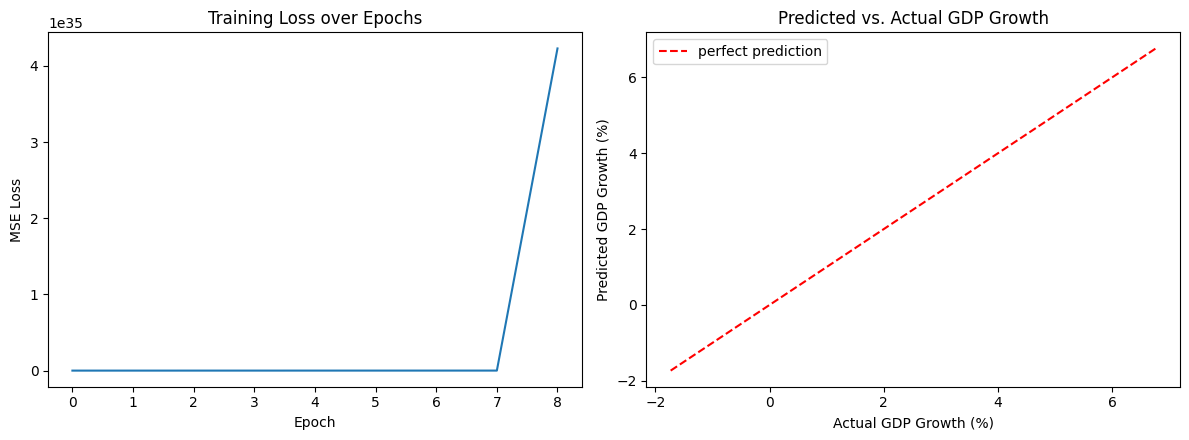

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss over Epochs")

with torch.no_grad():
    predicted = model(X).numpy().flatten()

axes[1].scatter(Y.numpy().flatten(), predicted, alpha=0.5)
lims = [Y.min().item() - 1, Y.max().item() + 1]
axes[1].plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
axes[1].set_xlabel("Actual GDP Growth (%)")
axes[1].set_ylabel("Predicted GDP Growth (%)")
axes[1].set_title("Predicted vs. Actual GDP Growth")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Working with Datasets: `TensorDataset` & `DataLoader`

Real macroeconomic forecasting pipelines process decades of **quarterly panel data**, often across many countries or regions, in **mini-batches** shuffled every epoch so the model doesn't overfit to chronological artifacts (e.g. always seeing recessions clustered at the end of a sorted dataset).

We'll build a richer **macroeconomic indicators dataset** with 5 features per quarter, ready to feed into a neural network in the next sections.


In [16]:
np.random.seed(1)
n = 800

yield_spread = np.random.normal(1.0, 1.3, n)
unemployment_change = np.random.normal(0.0, 0.5, n)        # pp change vs. prior year
pmi = np.clip(np.random.normal(51, 5, n), 30, 70)           # ISM Purchasing Managers' Index (>50 = expansion)
stock_return = np.random.normal(6, 15, n)                   # trailing 12-month % return
inflation = np.clip(np.random.normal(3.0, 1.5, n), -1, 12)

macro_features_df = pd.DataFrame({
    "Yield Spread (pp)": yield_spread,
    "Unemployment Chg (pp, YoY)": unemployment_change,
    "ISM PMI": pmi,
    "Stock Return (%, 12m)": stock_return,
    "Inflation (%)": inflation,
})
macro_features_df.head()


,Yield Spread (pp),"Unemployment Chg (pp, YoY)",ISM PMI,"Stock Return (%, 12m)",Inflation (%)
0,3.111649,0.407172,52.455023,1.867784,2.004372
1,0.204717,0.390235,56.374499,23.085799,3.719605
2,0.313377,-0.732027,47.510950,32.463744,0.540242
3,-0.394859,-0.077246,48.108371,6.113406,4.463008
4,2.125030,-0.046216,46.762737,10.421093,0.681299


In [17]:
features = macro_features_df.values
# Dummy placeholder target for the DataLoader demo (real targets built per-project below)
dummy_target = (macro_features_df["Yield Spread (pp)"] < 0).astype(int).values

macro_dataset = TensorDataset(
    torch.tensor(features, dtype=torch.float32),
    torch.tensor(dummy_target, dtype=torch.long)
)

macro_loader = DataLoader(macro_dataset, batch_size=32, shuffle=True)

for batch_idx, (batch_features, batch_targets) in enumerate(macro_loader):
    print(f"Batch {batch_idx + 1}")
    print("Features shape:", batch_features.shape)
    print("Targets:", batch_targets[:10], "...")
    break


Batch 1
Features shape: torch.Size([32, 5])
Targets: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0]) ...


## 8. Building a Neural Network with `nn.Module`

Every custom PyTorch model:
- Calls `super().__init__()`, then defines layers as attributes in `__init__` (auto-registers parameters).
- Implements `forward(self, x)` to define the data flow.
- Is always invoked as `model(x)`, never `model.forward(x)` directly, so PyTorch's hooks and train/eval mode switching work correctly.

We'll design a classifier for **recession risk**: 5 leading-indicator features → 2 classes (*No recession in next 12 months* / *Recession in next 12 months*).


In [18]:
class RecessionRiskClassifier(nn.Module):
    def __init__(self, input_features, hidden1, hidden2, output_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, output_classes)

    def forward(self, x):
        a1 = F.relu(self.fc1(x))
        a2 = F.relu(self.fc2(a1))
        output = self.out(a2)   # raw logits; CrossEntropyLoss applies softmax internally
        return output


## 9. Project 2 — Recession Prediction from the Yield Curve & Leading Indicators

**Trending topic:** an **inverted yield curve** (short-term rates above long-term rates) is one of the most closely watched recession signals in economics — it has preceded most U.S. recessions since the 1960s, and the New York Fed publishes a running recession-probability model built on exactly this spread.

We'll build a labeled version of the dataset above: a negative yield spread, rising unemployment, a weakening PMI, and falling stocks all push recession risk up.


In [19]:
np.random.seed(7)
n = 1000

yield_spread = np.random.normal(1.0, 1.4, n)
unemployment_change = np.random.normal(0.0, 0.6, n)
pmi = np.clip(np.random.normal(51, 5.5, n), 30, 70)
stock_return = np.random.normal(6, 16, n)
inflation = np.clip(np.random.normal(3.0, 1.6, n), -1, 12)

# Latent "recession risk score": higher = more likely. Yield curve inversion is the dominant signal.
risk_score = (
    -1.3 * yield_spread
    + 0.9 * unemployment_change
    -0.06 * (pmi - 50)
    -0.02 * stock_return
    + 0.05 * (inflation - 3)
    + np.random.normal(0, 0.5, n)
)
recession = (risk_score > 0.2).astype(int)   # 1 = recession within 12 months, 0 = no recession

recession_df = pd.DataFrame({
    "Yield Spread (pp)": yield_spread, "Unemployment Chg (pp, YoY)": unemployment_change,
    "ISM PMI": pmi, "Stock Return (%, 12m)": stock_return, "Inflation (%)": inflation,
    "Recession": recession
})
print("Class balance:\n", recession_df["Recession"].value_counts(normalize=True))
recession_df.head()


Class balance:
 Recession
0    0.781
1    0.219
Name: proportion, dtype: float64


,Yield Spread (pp),"Unemployment Chg (pp, YoY)",ISM PMI,"Stock Return (%, 12m)",Inflation (%),Recession
0,3.366736,0.530933,50.584421,33.524623,3.665351,0
1,0.347688,-0.545471,53.799188,8.276159,2.576009,0
2,1.045948,0.681190,46.616846,6.535810,0.571995,0
3,1.570523,0.052111,53.866360,-14.166173,4.722721,0
4,-0.104492,0.451000,49.318384,10.965219,3.997722,1


In [20]:
torch.manual_seed(42)

X = recession_df.drop(columns="Recession").values
y = recession_df["Recession"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features (helps optimization converge faster/more reliably)
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

model = RecessionRiskClassifier(input_features=X_train.shape[1], hidden1=16, hidden2=8, output_classes=2)
print(model)


RecessionRiskClassifier(
  (fc1): Linear(in_features=5, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=2, bias=True)
)

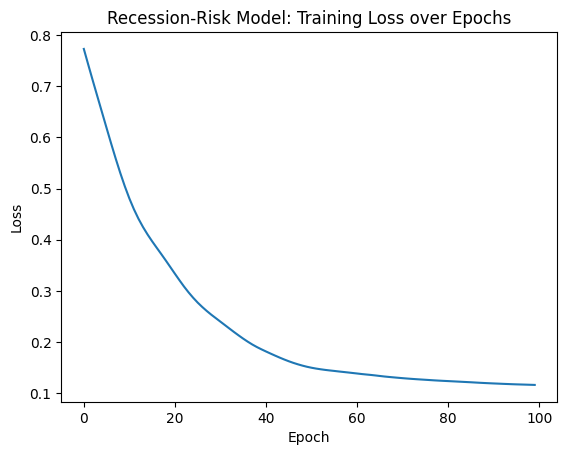

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
training_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer.step()
    training_losses.append(loss.item())

plt.plot(training_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Recession-Risk Model: Training Loss over Epochs")
plt.show()


In [22]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.softmax(test_logits, dim=1)[:, 1]   # probability of "recession"
    predicted_labels = torch.argmax(test_logits, dim=1)

accuracy = (predicted_labels == y_test).float().mean().item() * 100
print(f"Test accuracy: {accuracy:.2f}%")

# Simple confusion matrix
tp = ((predicted_labels == 1) & (y_test == 1)).sum().item()
tn = ((predicted_labels == 0) & (y_test == 0)).sum().item()
fp = ((predicted_labels == 1) & (y_test == 0)).sum().item()
fn = ((predicted_labels == 0) & (y_test == 1)).sum().item()
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}")
precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
print(f"Precision (of flagged quarters, % truly heading to recession): {precision*100:.1f}%")
print(f"Recall (of true recessions, % caught in advance): {recall*100:.1f}%")


Test accuracy: 93.50%
TP=37  FN=7  FP=6  TN=150
Precision (of flagged quarters, % truly heading to recession): 86.0%
Recall (of true recessions, % caught in advance): 84.1%


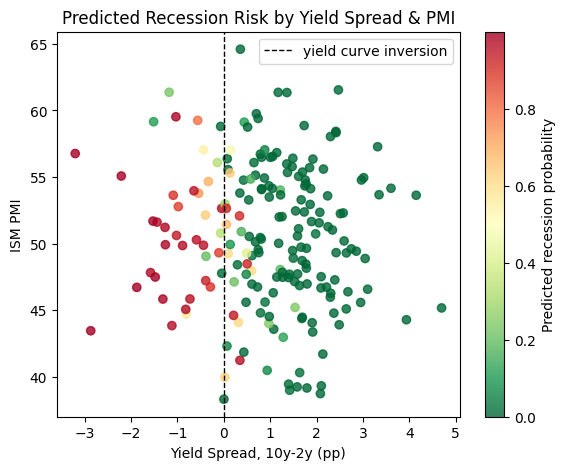

In [23]:
# Visualize predicted recession probability vs. yield spread and PMI
X_test_np = X_test.numpy() * X_std + X_mean   # de-standardize for interpretable axes
plt.figure(figsize=(6.5, 5))
sc = plt.scatter(X_test_np[:, 0], X_test_np[:, 2], c=test_probs.numpy(), cmap="RdYlGn_r", alpha=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="yield curve inversion")
plt.colorbar(sc, label="Predicted recession probability")
plt.xlabel("Yield Spread, 10y-2y (pp)")
plt.ylabel("ISM PMI")
plt.title("Predicted Recession Risk by Yield Spread & PMI")
plt.legend()
plt.show()


**Why this matters:** notice how risk concentrates to the left of the dashed line (yield curve inversion, spread < 0) and at low PMI readings (below the expansion/contraction threshold of 50) — mirroring the real-world signals economists watch. `precision` tells you how often a recession call is right (avoiding false alarms that spook markets), while `recall` tells you what fraction of actual recessions the model would have caught in advance.

## 10. Project 3 — Challenge: Economic Regime Classification

**Trending topic: regime-switching models for monetary policy & asset allocation.** Rather than a binary recession flag, central banks and asset managers often classify the economy into **regimes** — Expansion, Slowdown, Recession — to guide interest-rate decisions and portfolio tilts.

This mirrors the workflow of Project 2 but as a **3-class** problem — confirm you can reproduce the full pipeline independently: build data → split → tensors → model → train → evaluate → visualize.


In [24]:
np.random.seed(3)
n = 900

gdp_growth = np.random.normal(2.0, 2.2, n)
unemployment = np.clip(np.random.normal(5.5, 1.8, n), 2, 14)
inflation = np.clip(np.random.normal(3.0, 1.7, n), -1, 12)
leading_index = np.random.normal(0, 1.5, n)

# Composite health score -> tiered into 3 economic regimes
composite = 1.0*gdp_growth - 0.5*(unemployment - 5) - 0.3*abs(inflation - 2) + 0.6*leading_index
composite += np.random.normal(0, 0.7, n)

# Discretize into terciles: 0 = Recession, 1 = Slowdown, 2 = Expansion
thresholds = np.quantile(composite, [1/3, 2/3])
regime = np.digitize(composite, thresholds)

regime_df = pd.DataFrame({
    "GDP Growth (%)": gdp_growth, "Unemployment (%)": unemployment,
    "Inflation (%)": inflation, "Leading Index": leading_index,
    "Regime": regime  # 0=Recession, 1=Slowdown, 2=Expansion
})
print(regime_df["Regime"].value_counts().sort_index())
regime_df.head()


Regime
0    300
1    300
2    300
Name: count, dtype: int64


,GDP Growth (%),Unemployment (%),Inflation (%),Leading Index,Regime
0,5.934983,5.901425,-0.033984,1.544075,2
1,2.960322,6.806312,1.798601,1.299419,1
2,2.212294,5.465119,4.628664,0.027764,1
3,-2.099684,6.899722,4.923461,-1.986766,0
4,1.389746,7.776528,2.370457,1.582715,1


In [25]:
torch.manual_seed(42)

X = regime_df.drop(columns="Regime").values
y = regime_df["Regime"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)


class RegimeModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


input_size = X.shape[1]
output_size = len(np.unique(y))   # 3 regimes
model_regime = RegimeModel(input_size=input_size, hidden_size=16, output_size=output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_regime.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model_regime(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

model_regime.eval()
with torch.no_grad():
    y_test_pred = model_regime(X_test_tensor)
    y_test_pred_labels = torch.argmax(y_test_pred, dim=1)

accuracy = (y_test_pred_labels == y_test_tensor).sum().item() / len(y_test) * 100
print(f"\nTest accuracy: {accuracy:.2f}%")


Epoch 0, Loss: 1.0720
Epoch 20, Loss: 0.6447
Epoch 40, Loss: 0.4136


Epoch 60, Loss: 0.3563
Epoch 80, Loss: 0.3417

Test accuracy: 81.11%


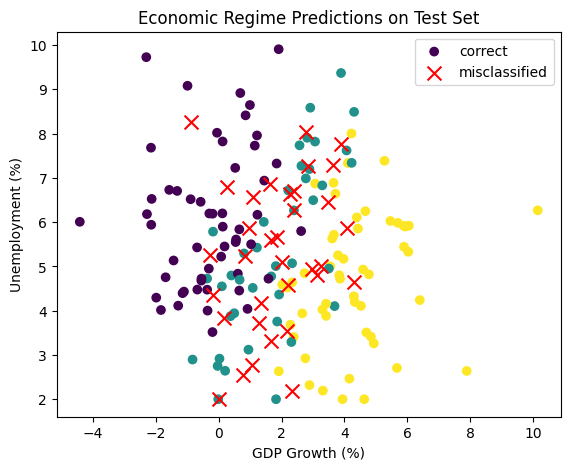

Legend: 0 = Recession | 1 = Slowdown | 2 = Expansion


In [26]:
# Visualize predictions vs. ground truth on two informative features
labels = {0: "Recession", 1: "Slowdown", 2: "Expansion"}
X_test_display = X_test * X_std + X_mean   # de-standardize for interpretable axes

correct = (y_test_pred_labels == y_test_tensor).numpy()
plt.figure(figsize=(6.5, 5))
sc = plt.scatter(X_test_display[correct, 0], X_test_display[correct, 1],
                  c=y_test[correct], cmap="viridis", label="correct", marker="o")
plt.scatter(X_test_display[~correct, 0], X_test_display[~correct, 1],
            c="red", marker="x", s=100, label="misclassified")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Unemployment (%)")
plt.title("Economic Regime Predictions on Test Set")
plt.legend()
plt.show()

print("Legend: 0 =", labels[0], "| 1 =", labels[1], "| 2 =", labels[2])


## 11. Wrap-up & Key Takeaways

- **Tensors** naturally represent economic data: a vector per quarter, a matrix per country/time panel, a 3D tensor for multi-country, multi-quarter indicator series.
- **`torch.zeros/ones/arange/linspace/rand/randn/randint`** cover initializing placeholder panels, quarter indices, rate-scenario grids, and model weights.
- **`view`/`reshape`/`unsqueeze`/`squeeze`** turn flat statistical-agency exports into the `(observations, indicators)` shape models expect.
- **Autograd** automatically computes how each model parameter should change to reduce prediction error — the same math whether nowcasting GDP or flagging recession risk.
- **The training loop** is always: `forward → loss → zero_grad → backward → step`.
- **`nn.Module`** organizes any model — from a two-feature linear regressor to a multi-layer recession classifier.
- **`TensorDataset` + `DataLoader`** batch and shuffle decades of panel data efficiently.
- **`model.eval()` + `torch.no_grad()`** are essential for trustworthy, efficient inference once a forecasting model is deployed.

### From notebook to real macroeconomic forecasting

To adapt these projects to real-world use, you'd:
1. Replace synthetic data with real series from sources like **FRED** (Federal Reserve Economic Data), the **OECD**, or the **IMF**.
2. Account for **time-series structure explicitly** — use lagged features, rolling windows, or recurrent/temporal architectures (LSTMs, temporal convolutions) rather than treating quarters as independent, i.i.d. rows.
3. Guard against **regime change and structural breaks** — a model trained on pre-2020 data may not generalize to a pandemic-era or post-pandemic economy.
4. Backtest carefully using **only information available at the time** (avoid look-ahead bias) — a recurring pitfall in economic and financial forecasting.

The underlying PyTorch mechanics — tensors, autograd, `nn.Module`, and the training loop — stay exactly the same across all of these real-world extensions.
